In [1]:
import pandas as pd

long_df = pd.read_csv("annotation_efficiency_filtered_long.csv")
wide_df = pd.read_csv("annotation_efficiency_filtered_wide.csv")
summ_df = pd.read_csv("annotation_efficiency_filtered_summary_by_mode.csv")

summ_df

,Unnamed: 0,lead_time,lead_time.1,total_bubbles,sec_per_bubble,sec_per_bubble.1,bubbles_per_min,bubbles_per_min.1
0,NaN,mean,median,mean,mean,median,mean,median
1,mode,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,manual_only,179.18428571428572,170.69,16.5,16.798390733490113,12.295874999999999,5.213133416004039,4.882000190348352
3,preannotations_only,57.066,45.404,16.357142857142858,11.83212323879824,8.484363636363637,25.059573740733736,7.071832676152923
4,preannotations_plus_sam2,25.11266666666667,15.341,16.642857142857142,3.204895807279141,3.0559999999999996,40.874205949114135,19.63350785340314


## % gains between modes (per image)

In [2]:
import numpy as np

df = wide_df.copy()

# Rename to something shorter
t_man  = df["lead_time_manual_only"]
t_pre  = df["lead_time_preannotations_only"]
t_sam  = df["lead_time_preannotations_plus_sam2"]

# Percentage reduction in time per image
df["pct_reduction_manual_to_pre"] = 100 * (t_man - t_pre) / t_man
df["pct_reduction_manual_to_sam"] = 100 * (t_man - t_sam) / t_man
df["pct_reduction_pre_to_sam"]    = 100 * (t_pre - t_sam) / t_pre

df[[
    "filename",
    "pct_reduction_manual_to_pre",
    "pct_reduction_manual_to_sam",
    "pct_reduction_pre_to_sam",
]].head()

,filename,pct_reduction_manual_to_pre,pct_reduction_manual_to_sam,pct_reduction_pre_to_sam
0,10x_qc1_qd2_23_00002.jpg,60.482870,87.378213,68.059961
1,10x_qc1_qd2_2_00002.jpg,31.840462,89.699188,84.887203
2,10x_qc1_qd2_3_00004.jpg,55.802955,87.097279,70.806371
3,agua2SDS_minOIL_qc16_qd1_form_00000.jpg,64.002092,89.104004,69.731586
4,agua2SDS_minOIL_qc4_qd1_form_00000.jpg,61.630614,73.386344,30.638308


In [3]:
df[[
    "pct_reduction_manual_to_pre",
    "pct_reduction_manual_to_sam",
    "pct_reduction_pre_to_sam",
]].describe()

,pct_reduction_manual_to_pre,pct_reduction_manual_to_sam,pct_reduction_pre_to_sam
count,9.000000,9.000000,9.000000
mean,61.743342,85.535212,47.132780
std,18.720895,6.784910,49.322831
min,31.840462,73.386344,-75.731213
25%,54.866647,80.264639,40.307999
50%,60.482870,87.378213,68.059961
75%,64.002092,89.104004,70.806371
max,92.189281,95.337625,84.887203


# Plot time per image by mode (paired, per-image lines)

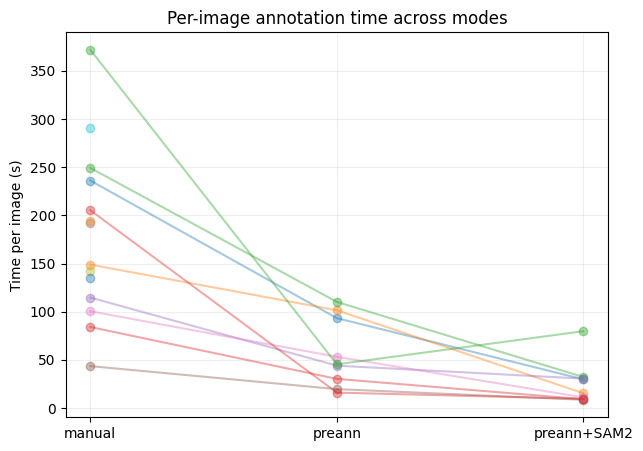

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for _, row in wide_df.iterrows():
    plt.plot(
        ["manual", "preann", "preann+SAM2"],
        [
            row["lead_time_manual_only"],
            row["lead_time_preannotations_only"],
            row["lead_time_preannotations_plus_sam2"],
        ],
        marker="o",
        alpha=0.4
    )

plt.ylabel("Time per image (s)")
plt.title("Per-image annotation time across modes")
plt.grid(True, alpha=0.2)
plt.show()

# Boxplot / violin plot per mode (overall distributions)

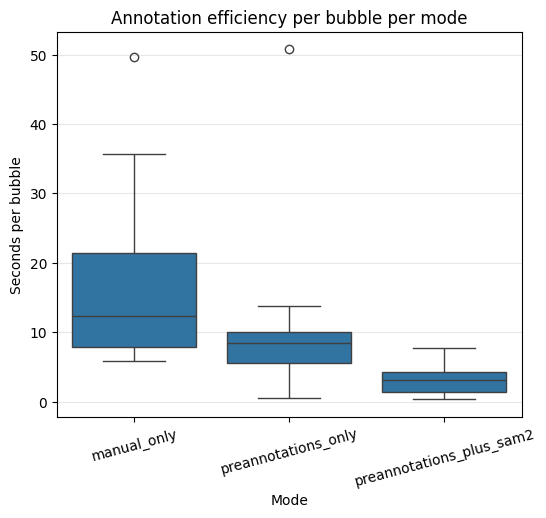

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(
    data=long_df,
    x="mode",
    y="sec_per_bubble",
    order=["manual_only", "preannotations_only", "preannotations_plus_sam2"]
)
plt.ylabel("Seconds per bubble")
plt.xlabel("Mode")
plt.title("Annotation efficiency per bubble per mode")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()